##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install -q keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 29.7 MB/s eta 0:00:00


Found image files:
lab4-1.png -> lab4-1.png
lab4-2.png -> lab4-2.png
lab4-3.png -> lab4-3.png
lab4-4.png -> lab4-4.png
lab4-5.png -> lab4-5.png
Batch shape: (5, 640, 640, 3)


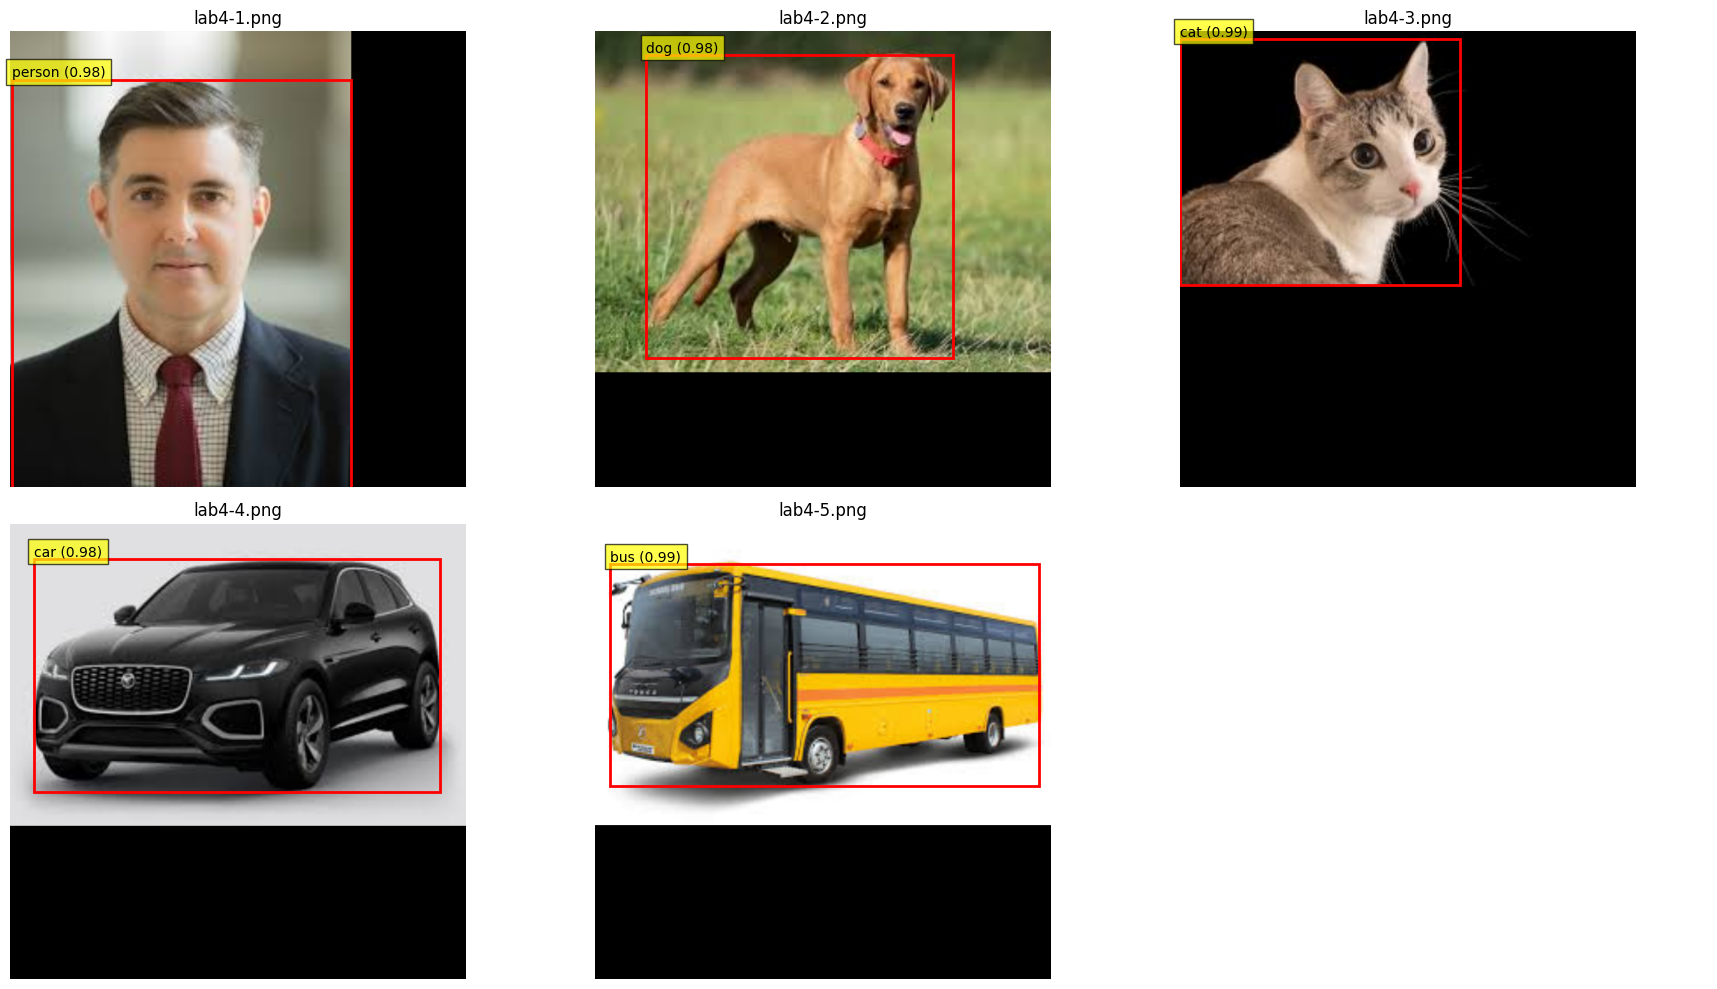

,Image File,Expected Object,Detected Objects + Confidence,Correct?,Missed Objects,Incorrect Labels
0,lab4-1.png,person,person (0.98),Yes,None,None
1,lab4-2.png,dog,dog (0.98),Yes,None,None
2,lab4-3.png,cat,cat (0.99),Yes,None,None
3,lab4-4.png,car,car (0.98),Yes,None,None
4,lab4-5.png,bus,bus (0.99),Yes,None,None


In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
import keras_cv

class_mapping = {
    0: "aeroplane",
    1: "bicycle",
    2: "bird",
    3: "boat",
    4: "bottle",
    5: "bus",
    6: "car",
    7: "cat",
    8: "chair",
    9: "cow",
    10: "diningtable",
    11: "dog",
    12: "horse",
    13: "motorbike",
    14: "person",
    15: "pottedplant",
    16: "sheep",
    17: "sofa",
    18: "train",
    19: "tvmonitor",
}

def find_file(filename):
    matches = [p for p in Path(".").rglob(filename) if p.is_file()]
    if not matches:
        raise FileNotFoundError(f"Could not find {filename}")
    return str(matches[0])

image_files = {
    "lab4-1.png": find_file("lab4-1.png"),
    "lab4-2.png": find_file("lab4-2.png"),
    "lab4-3.png": find_file("lab4-3.png"),
    "lab4-4.png": find_file("lab4-4.png"),
    "lab4-5.png": find_file("lab4-5.png"),
}

print("Found image files:")
for k, v in image_files.items():
    print(k, "->", v)

expected_objects = {
    "lab4-1.png": ["person"],
    "lab4-2.png": ["dog"],
    "lab4-3.png": ["cat"],
    "lab4-4.png": ["car"],
    "lab4-5.png": ["bus"],
}

detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

resized_images = []
image_keys = list(image_files.keys())

for key in image_keys:
    img = keras.utils.load_img(image_files[key])
    img = np.array(img)
    resized = inference_resizing(img)
    resized = tf.cast(resized, tf.float32).numpy()
    resized_images.append(resized)

resized_images = np.stack(resized_images, axis=0)
print("Batch shape:", resized_images.shape)

y_pred = detector.predict(resized_images, verbose=0)

score_threshold = 0.25

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, key in enumerate(image_keys):
    img = resized_images[i].astype("uint8")
    ax = axes[i]
    ax.imshow(img)
    ax.set_title(key)
    ax.axis("off")

    boxes = y_pred["boxes"][i]
    classes = y_pred["classes"][i]
    confidences = y_pred["confidence"][i]

    for box, cls_id, conf in zip(boxes, classes, confidences):
        cls_id = int(cls_id)
        conf = float(conf)

        if conf < score_threshold or cls_id < 0:
            continue

        x, y, w, h = box
        label = class_mapping.get(cls_id, f"class_{cls_id}")

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x, max(0, y - 5),
            f"{label} ({conf:.2f})",
            fontsize=10,
            bbox=dict(facecolor="yellow", alpha=0.7)
        )

for j in range(len(image_keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

def summarize_predictions(pred_classes, pred_confidences, threshold=0.25):
    best_by_label = {}

    for cls_id, conf in zip(pred_classes, pred_confidences):
        cls_id = int(cls_id)
        conf = float(conf)

        if conf < threshold or cls_id < 0:
            continue

        label = class_mapping.get(cls_id, f"class_{cls_id}")
        if label not in best_by_label or conf > best_by_label[label]:
            best_by_label[label] = conf

    return best_by_label

rows = []

for i, key in enumerate(image_keys):
    pred_classes = y_pred["classes"][i]
    pred_confidences = y_pred["confidence"][i]

    detected = summarize_predictions(pred_classes, pred_confidences)

    expected = expected_objects.get(key, [])
    correct_detected = [obj for obj in expected if obj in detected]
    missed = [obj for obj in expected if obj not in detected]
    incorrect = [obj for obj in detected if obj not in expected]

    detected_text = ", ".join(
        [f"{label} ({score:.2f})" for label, score in detected.items()]
    ) if detected else "No objects detected"

    rows.append({
        "Image File": key,
        "Expected Object": ", ".join(expected),
        "Detected Objects + Confidence": detected_text,
        "Correct?": "Yes" if len(correct_detected) > 0 else "No",
        "Missed Objects": ", ".join(missed) if missed else "None",
        "Incorrect Labels": ", ".join(incorrect) if incorrect else "None",
    })

results_df = pd.DataFrame(rows)
results_df